## scPortrait workflow with DAPI Segmentation method

In [19]:
import os
import matplotlib.pyplot as plt
import numpy as np

from scportrait.pipeline.segmentation.workflows import DAPISegmentation
from scportrait.pipeline.featurization import CellFeaturizer
from scportrait.pipeline.extraction import HDF5CellExtraction
from scportrait.pipeline.project import Project

import yaml
from IPython.display import Markdown

In [20]:
# Generate the project structure for cropped dataset from 01_prepare_xenium_data.ipynb

project_location = "../data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project"
config_file = "../configs/dapi_segmentation_config.yml"
project = Project(
    os.path.abspath(project_location),
    config_path=config_file,
    overwrite=True,
    debug=True,
    segmentation_f=DAPISegmentation,
    extraction_f=HDF5CellExtraction,
    featurization_f=CellFeaturizer
)

Updating project config file.
[29/06/2026 02:13:54] Loading config from /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/config.yml
[29/06/2026 02:13:54] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.
[29/06/2026 02:13:54] Compression algorithm for extracted single-cell images: lzf
[29/06/2026 02:13:54] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.


/tmp/ipykernel_2206320/1672235315.py:5: UserWarning: There is already a directory in the location path
  project = Project(


In [21]:
# Import the cropped Xenium dataset into the project structure

tif_file_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped_morphology_focus_rescaled.ome.tif"

project.load_input_from_tif_files(file_paths = [tif_file_path], overwrite=True)

[29/06/2026 02:14:12] Output location /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata already exists. Overwriting.
[29/06/2026 02:14:12] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/Project_4nlsge82 for Project
[29/06/2026 02:14:13] Image input_image written to sdata object.
[29/06/2026 02:14:14] Cleaned up temporary directory at <TemporaryDirectory '/scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/Project_4nlsge82'>


In [22]:
project.print_project_status()

[29/06/2026 02:14:19] Current Project Status:
[29/06/2026 02:14:19] --------------------------------
[29/06/2026 02:14:19] Input Image in sdata: True
[29/06/2026 02:14:19] Nucleus Segmentation in sdata: False
[29/06/2026 02:14:19] Cytosol Segmentation in sdata: False
[29/06/2026 02:14:19] Nucleus Centers in sdata: False
[29/06/2026 02:14:19] Cytosol Centers in sdata: False
[29/06/2026 02:14:19] Extracted single-cell images saved to file: False
[29/06/2026 02:14:19] --------------------------------


In [23]:
# Inspect the project object
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
└── Images
      └── 'input_image': DataTree[cyx] (1, 4499, 3999), (1, 2249, 1999), (1, 562, 499), (1, 70, 62)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images)

In [24]:
project.input_image

<xarray.DataArray 'image' (c: 1, y: 4499, x: 3999)> Size: 36MB
dask.array<from-zarr, shape=(1, 4499, 3999), dtype=uint16, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U1 4B '.'
  * y        (y) float64 36kB 0.5 1.5 2.5 3.5 ... 4.496e+03 4.498e+03 4.498e+03
  * x        (x) float64 32kB 0.5 1.5 2.5 3.5 ... 3.996e+03 3.998e+03 3.998e+03
Attributes:
    transform:  {'global': Identity }

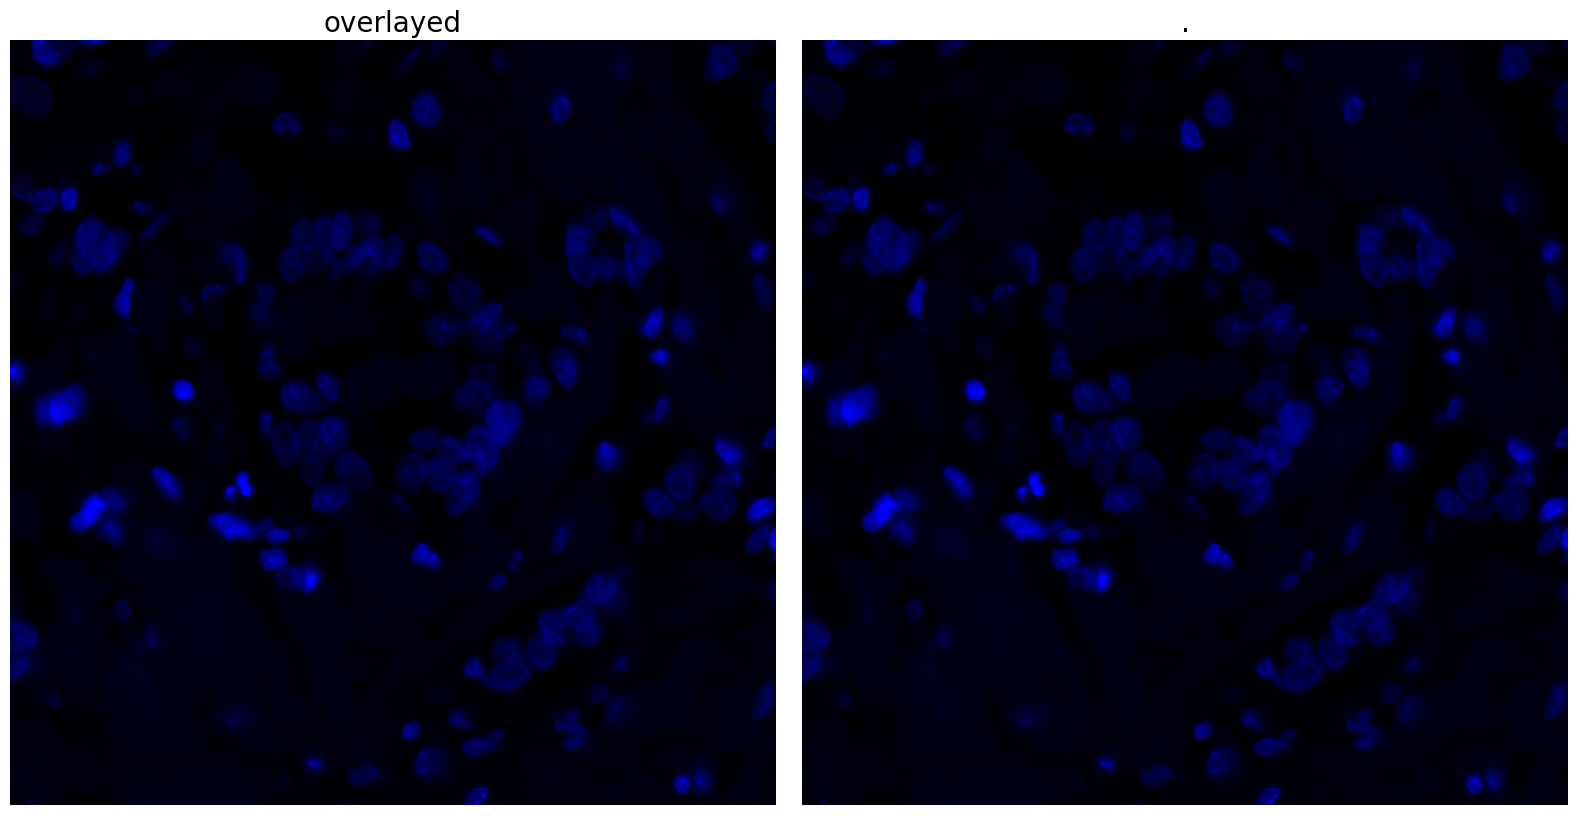

In [25]:
project.plot_input_image()

## Segmentation

In [26]:
display(Markdown(f"```yaml\n{yaml.dump(project.segmentation_f.config, default_flow_style=False)}\n```"))

```yaml
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
chunk_size: 50
lower_quantile_normalization: 0.001
median_filter_size: 4
nucleus_segmentation:
  contact_filter: 0.5
  dilation: 0
  lower_quantile_normalization: 0.01
  max_size: 5000
  median_block: 41
  median_step: 4
  min_distance: 8
  min_size: 150
  peak_footprint: 7
  speckle_kernel: 9
  threshold: 0.2
  upper_quantile_normalization: 0.99
upper_quantile_normalization: 0.999

```

In [27]:
print(project.input_image.shape)

(1, 4499, 3999)


In [28]:
print(project.input_image.dtype)

uint16


In [29]:
print(project.segmentation_f.debug)

True


In [30]:
project.segmentation_f.debug = False
project.segment()

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/scportrait/pipeline/_utils/segmentation.py:96: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  image_mask_clean = binary_erosion(image_mask, footprint=disk(speckle_kernel))


[29/06/2026 02:15:35] Segmentation seg_all_nucleus written to sdata object.
[29/06/2026 02:15:36] Points centers_seg_all_nucleus written to sdata object.


[29/06/2026 02:02:29] Normalization of the input image will be performed.
[29/06/2026 02:02:29] Normalizing each channel to the same range


TypeError: 'Axes' object is not subscriptable

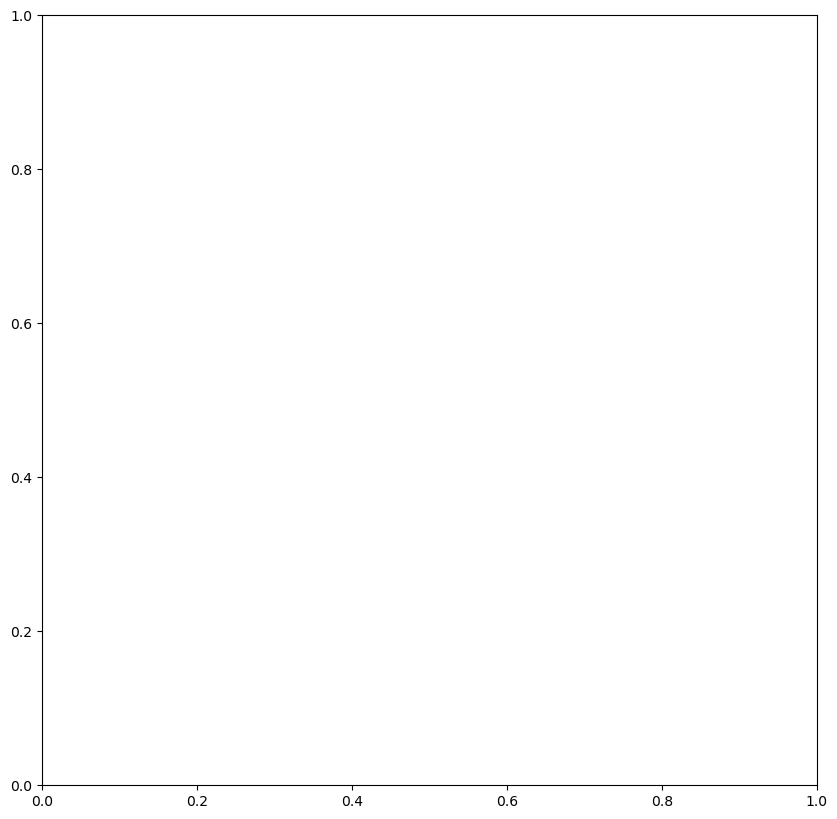

In [10]:
project.segment()

In [31]:
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4499, 3999), (1, 2249, 1999), (1, 562, 499), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4499, 3999), (2249, 1999), (562, 499), (70, 62)
└── Points
      └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

## Single-cell extraction

In [32]:
# Extracting single cell images (cell segmentation only, no nucleus segmentation masks)
display(Markdown(f"```yaml\n{yaml.dump(project.extraction_f.config, default_flow_style=False)}\n```"))

```yaml
cache: .
compression: true
image_size: 64
normalize_output: false
segmentation_mask: seg_all_nucleus
threads: 8

```

In [33]:
project.extract()

[29/06/2026 02:16:10] Initialized temporary directory at ./HDF5CellExtraction_5lfnagfb for HDF5CellExtraction
[29/06/2026 02:16:10] Created new directory for extraction results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data
[29/06/2026 02:16:10] Setup output folder at /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data
[29/06/2026 02:16:10] Found 1 segmentation masks for the given key in the sdata object. Will be extracting single-cell images based on these masks: ['seg_all_nucleus']
[29/06/2026 02:16:10] Using seg_all_nucleus as the main segmentation mask to determine cell centers.
[29/06/2026 02:16:10] A total of 30 cells were too close to the image border to be extracted. Their cell_ids were saved to file /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentatio

Extracting cell batches:   0%|          | 0/8 [00:00<?, ?it/s]

[29/06/2026 02:16:16] Finished extraction in 5.18 seconds (461.58 cells / second)
[29/06/2026 02:16:17] Benchmarking times saved to file.
[29/06/2026 02:16:17] Cleaned up temporary directory at ./HDF5CellExtraction_5lfnagfb


In [34]:
project.h5sc

AnnData object with n_obs × n_vars = 2392 × 2
    obs: 'scportrait_cell_id'
    var: 'channels', 'channel_mapping'
    uns: 'single_cell_images'
    obsm: 'single_cell_images'

In [35]:
display("Single cell image dataset:", project.h5sc.obsm["single_cell_images"])
display("Metadata:", project.h5sc.uns["single_cell_images"])

'Single cell image dataset:'

<HDF5 dataset "single_cell_images": shape (2392, 2, 64, 64), type "<f2">

'Metadata:'

{'channel_mapping': array(['mask', 'image_channel'], dtype=object),
 'channel_names': array(['seg_all_nucleus', '.'], dtype=object),
 'compression': 'lzf',
 'image_size': 64,
 'n_cells': 2392,
 'n_channels': 2,
 'n_image_channels': 1,
 'n_masks': 1,
 'normalization': False,
 'normalization_range_lower': 'None',
 'normalization_range_upper': 'None'}

In [36]:
project.h5sc.obs

,scportrait_cell_id
0,1
1,2
2,3
3,4
4,5
...,...
2387,2502
2388,2503
2389,2504
2390,2505


(2, 64, 64)


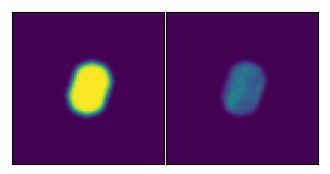

In [39]:
import scportrait

cell_id = 2502
image_of_cell = scportrait.tl.h5sc.get_image_with_cellid(project.h5sc, cell_id)
print(image_of_cell.shape)
fig, axs = plt.subplots(1, 1, figsize=(2 * 2, 2))
scportrait.pl.h5sc._plot_image_grid(ax=axs, images=image_of_cell, nrows=1, ncols=2)

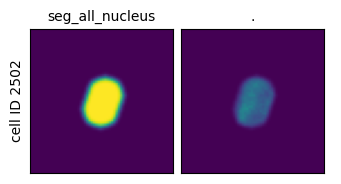

In [40]:
scportrait.pl.cell_grid(project.h5sc, cell_ids=cell_id)

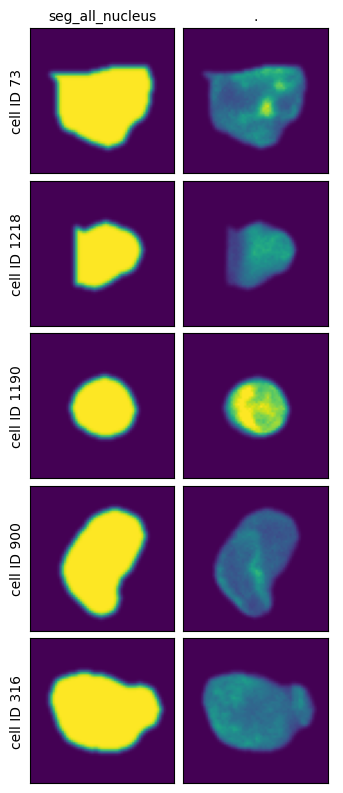

In [41]:
project.plot_single_cell_images()


## Deep learning

In [42]:
display(Markdown(f"```yaml\n{yaml.dump(project.featurization_f.config, default_flow_style=False)}\n```"))

```yaml
batch_size: 900
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
dataloader_worker_number: 0
inference_device: cpu

```

In [43]:
project.featurize(overwrite = True)

Using extraction directory: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc
[29/06/2026 02:28:33] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_z0id47ji for CellFeaturizer
[29/06/2026 02:28:33] Started CellFeaturization of all available channels.
[29/06/2026 02:28:33] Created new directory for featurization results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/featurization/complete_CellFeaturizer
[29/06/2026 02:28:33] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_p4vzgxmz for CellFeaturizer
[29/06/2026 02:28:33] Reading data from path: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[29/06/2026 02:28:34] Table CellFeaturizer_nucleus written to sdata object.
[29/06/2026 02:28:35] GPU memory before performing cleanup: None
[29/06/2026 02:28:35] GPU memory after performing cleanup: None
[29/06/2026 02:28:35] Cleaned up temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_p4vzgxmz


## Generated Results

In [44]:
results = project.sdata["CellFeaturizer_nucleus"].to_df()


In [45]:
print(results.head())

   nucleus_area  ._mean_nucleus  ._median_nucleus  ._quant75_nucleus  \
0        3581.0        0.402034          0.431885           0.552246   
1        3865.0        0.308903          0.339844           0.393555   
2        3754.0        0.343146          0.348877           0.447144   
3        3622.0        0.246366          0.277344           0.330078   
4        3332.0        0.275194          0.315918           0.385498   

   ._quant25_nucleus  ._summed_intensity_nucleus  \
0           0.322266                 1439.682129   
1           0.266846                 1193.908569   
2           0.261475                 1288.169800   
3           0.219482                  892.338684   
4           0.195801                  916.947083   

   ._summed_intensity_area_normalized_nucleus  
0                                    0.402034  
1                                    0.308903  
2                                    0.343146  
3                                    0.246366  
4             

In [46]:
results["nucleus_area"].describe()

count    2392.000000
mean     1312.174316
std       541.108032
min       493.000000
25%       932.750000
50%      1218.000000
75%      1551.250000
max      3879.000000
Name: nucleus_area, dtype: float64

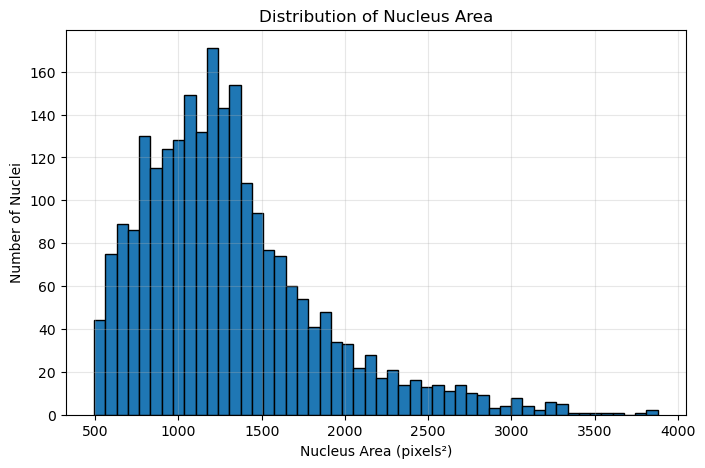

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(results["nucleus_area"], bins=50, edgecolor="black")

plt.title("Distribution of Nucleus Area")
plt.xlabel("Nucleus Area (pixels²)")
plt.ylabel("Number of Nuclei")

plt.grid(alpha=0.3)
plt.show()